In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("Fatalities.csv")

In [3]:
# 2. Datetime Parsing & Delay Calculation
df["date_of_event"] = pd.to_datetime(df["date_of_event"], errors="coerce")
df["date_of_death"] = pd.to_datetime(df["date_of_death"], errors="coerce")

df["event_year"] = df["date_of_event"].dt.year
df["event_month"] = df["date_of_event"].dt.strftime("%B")
df["days_to_death"] = (df["date_of_death"] - df["date_of_event"]).dt.days

In [4]:
# 3. Handling Missing Values
df["took_part_in_the_hostilities"] = df["took_part_in_the_hostilities"].fillna(
    "Unknown"
)
df["event_location_region"] = df["event_location_region"].fillna("Unknown")
df["type_of_injury"] = df["type_of_injury"].fillna("Unknown")
df["killed_by"] = df["killed_by"].fillna("Unknown")

In [5]:
# 4. Feature Engineering: Age Binning
bins = [-1, 12, 17, 35, 60, 120]
labels = [
    "Child (0-12)",
    "Minor (13-17)",
    "Young Adult (18-35)",
    "Adult (36-60)",
    "Senior (60+)",
]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

### Combining grouping and filtering (example: average age of males and females from a specific nationality involved in specific injuries)

In [16]:
df[(df['citizenship'] == 'Palestinian') & (df['type_of_injury'] == 'stones throwing')].groupby('gender')['age'].mean()

gender
F    45.0
M    47.0
Name: age, dtype: float64

### Time-based analysis (grouping by year and month)

In [17]:
import seaborn as sns
# Time-based analysis (events at specific times)
df['date_of_event'] = pd.to_datetime(df['date_of_event'])
df['year'] = df['date_of_event'].dt.year
df['month'] = df['date_of_event'].dt.month_name()  # Format month as month name
time_events = df.groupby(['year', 'month']).size().reset_index(name='incident_count')
time_events['year_month'] = time_events['month'] + ' ' + time_events['year'].astype(str)
time_events

,year,month,incident_count,year_month
0,2000,December,10,December 2000
1,2000,November,17,November 2000
2,2000,October,8,October 2000
3,2001,April,4,April 2001
4,2001,August,26,August 2001
...,...,...,...,...
262,2023,July,25,July 2023
263,2023,June,24,June 2023
264,2023,March,25,March 2023
265,2023,May,53,May 2023


#### Grouping and Pivot Tables:

<Axes: xlabel='citizenship'>

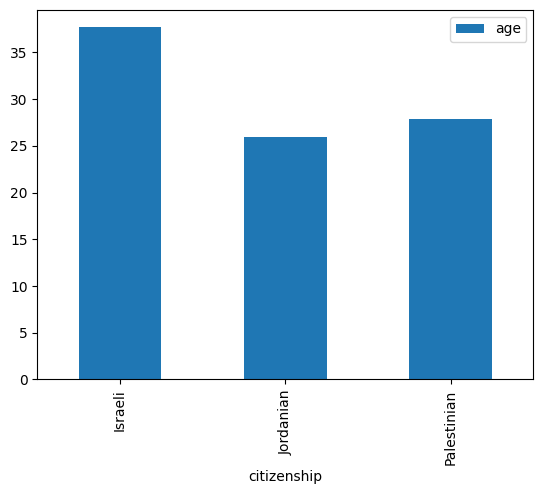

In [18]:
female_age = pd.pivot_table(df[df['gender'] == 'F'], values='age', index=['citizenship'], aggfunc='mean')
female_age.plot(kind='bar')

<Axes: xlabel='citizenship'>

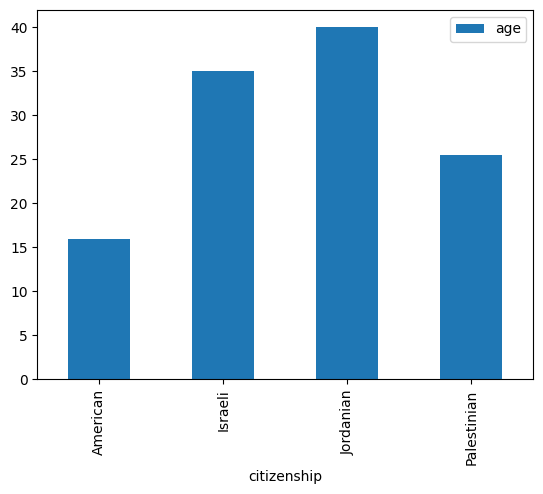

In [19]:
male_age = pd.pivot_table(df[df['gender'] == 'M'], values='age', index=['citizenship'], aggfunc='mean')
male_age.plot(kind='bar')

### Filtering with Multiple Conditions:
You can filter data with multiple conditions. For example, filtering incidents where individuals of a specific gender and nationality were 
involved and the injury type was specific.
filtered_data = df[(df['citizenship'] == 'YourNationality') & (df['gender'] == 'YourGender') & (df['type_of_injury'] == 'YourInjuryType')]

In [21]:
df[(df['citizenship'] == 'Palestinian') & (df['gender'] == 'F') & (df['type_of_injury'] == 'gunfire')] [['citizenship','gender','type_of_injury']]

,citizenship,gender,type_of_injury
73,Palestinian,F,gunfire
114,Palestinian,F,gunfire
121,Palestinian,F,gunfire
122,Palestinian,F,gunfire
124,Palestinian,F,gunfire
...,...,...,...
10923,Palestinian,F,gunfire
10928,Palestinian,F,gunfire
10937,Palestinian,F,gunfire
10939,Palestinian,F,gunfire
